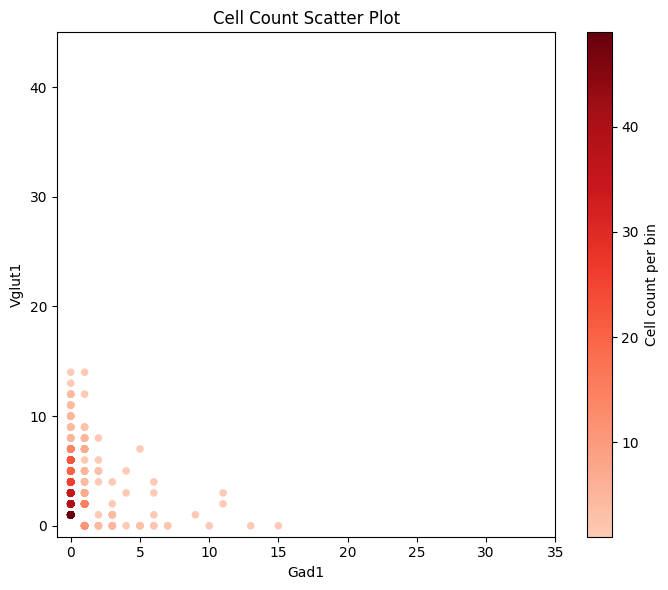

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

csv_path = r"Y:\Huihui\HH\BARseq2_01202026\Analysis_BARseq2_Transcriptome\Barcode_Gene\Brain1_1\STARmap_output\BARseq2_Barcoded_cell_gad1_vglut1.xlsx"
df = pd.read_excel(csv_path)

x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

# plot range
xlim = [-1, 35]
ylim = [-1, 45]

# count cells in local bins
bins = 50
counts, xedges, yedges = np.histogram2d(
    x, y,
    bins=bins,
    range=[xlim, ylim]
)

# find which bin each point belongs to
xbin = np.digitize(x, xedges) - 1
ybin = np.digitize(y, yedges) - 1

# keep valid points
valid = (
    (xbin >= 0) & (xbin < bins) &
    (ybin >= 0) & (ybin < bins)
)

x_plot = x[valid]
y_plot = y[valid]
point_counts = counts[xbin[valid], ybin[valid]]

reds_truncated = LinearSegmentedColormap.from_list(

    "truncated_Reds",

    plt.cm.Reds(np.linspace(0.2, 1, 256))

)

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    x_plot, y_plot,
    s=30,
    c=point_counts,
    cmap=reds_truncated,
    alpha=1,
    marker="o",
    edgecolors="none",
    
)

plt.colorbar(sc, label="Cell count per bin")

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Cell Count Scatter Plot")

plt.xlim(xlim)
plt.ylim(ylim)

plt.tight_layout()

plt.savefig(
    r"Y:\Huihui\HH\BARseq2_01202026\Analysis_BARseq2_Transcriptome\Barcode_Gene\Brain1_1\STARmap_output\BARseq2_barcoded_cell_gad1_vglut1.eps",
    format="eps",
    bbox_inches="tight"
)

plt.show()